## 1. Import bibliotek



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier



## 2. Wczytanie danych


In [3]:
df = pd.read_csv('cleaned_finance_data (3).csv')


df = df.drop(columns=['nulls'])

df.shape

(9243, 24)

In [4]:
print("Lista kolumn:")
for col in df.columns:
    print("-", col)


Lista kolumn:
- gender
- age
- Investment_Avenues
- Mutual_Funds
- Equity_Market
- Debentures
- Government_Bonds
- Fixed_Deposits
- PPF
- Gold
- Stock_Marktet
- Factor
- Objective
- Purpose
- Duration
- Invest_Monitor
- Expect
- Avenue
- What are your savings objectives?
- Reason_Equity
- Reason_Mutual
- Reason_Bonds
- Reason_FD
- Source


## 3. Ustawienie zmiennej docelowej


In [5]:
TARGET = 'Avenue'

# Usuwamy rekordy bez targetu
model_df = df.dropna(subset=[TARGET]).copy()

print("Rozmiar po usunięciu braków targetu:", model_df.shape)
print("Rozkład targetu:")
print(model_df[TARGET].value_counts())
print("Rozkład procentowy:")
print((model_df[TARGET].value_counts(normalize=True) * 100).round(2))


Rozmiar po usunięciu braków targetu: (9243, 24)
Rozkład targetu:
Avenue
Mutual Fund              2372
Fixed Deposits           2355
Public Provident Fund    2300
Equity                   2216
Name: count, dtype: int64
Rozkład procentowy:
Avenue
Mutual Fund              25.66
Fixed Deposits           25.48
Public Provident Fund    24.88
Equity                   23.97
Name: proportion, dtype: float64


## 4. Podział na cechy X i target y
- `X` zawiera wszystkie kolumny poza `Avenue`.
- `y` zawiera zakodowaną numerycznie zmienną `Avenue`.

`LabelEncoder` zamienia nazwy klas, np. `Equity`, `Fixed Deposits`, na liczby, ponieważ modele klasyfikacyjne pracują na reprezentacji numerycznej.


In [6]:
X = model_df.drop(columns=[TARGET])
y_raw = model_df[TARGET]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Mapowanie klas:")
class_mapping


Mapowanie klas:


{'Equity': 0,
 'Fixed Deposits': 1,
 'Mutual Fund': 2,
 'Public Provident Fund': 3}

## 5. Rozpoznanie typów kolumn
Dane zawierają kolumny numeryczne oraz kategoryczne.

- numeryczne: uzupełnienie braków medianą,
- kategoryczne: uzupełnienie braków najczęstszą wartością i One-Hot Encoding.


In [12]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print("Kolumny numeryczne:", numeric_cols)
print("Kolumny kategoryczne:", categorical_cols)


Kolumny numeryczne: ['age', 'Mutual_Funds', 'Equity_Market', 'Debentures', 'Government_Bonds', 'Fixed_Deposits', 'PPF', 'Gold']
Kolumny kategoryczne: ['gender', 'Investment_Avenues', 'Stock_Marktet', 'Factor', 'Objective', 'Purpose', 'Duration', 'Invest_Monitor', 'Expect', 'What are your savings objectives?', 'Reason_Equity', 'Reason_Mutual', 'Reason_Bonds', 'Reason_FD', 'Source']


## 6. Preprocessing



In [13]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])


## 7. Podział danych na trening i test
Dzielimy dane w proporcji 80/20.

Używamy `stratify=y`, aby zachować podobny rozkład klas w zbiorze treningowym i testowym.


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (7394, 23)
Test: (1849, 23)


## 8. Definicja modeli
Porównujemy kilka modeli:

1. **DummyClassifier** — baseline, czyli punkt odniesienia.
2. **Logistic Regression** — prosty, interpretowalny model liniowy.
3. **Random Forest** — model drzewiasty, dobrze łapie nieliniowości.



In [15]:
models = {
    'Dummy most frequent': DummyClassifier(strategy='most_frequent'),
    'Dummy stratified': DummyClassifier(strategy='stratified', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )
}

models.keys()


dict_keys(['Dummy most frequent', 'Dummy stratified', 'Logistic Regression', 'Random Forest'])

## 9. Trenowanie i porównanie modeli
Każdy model jest opakowany w ten sam pipeline:

```text
preprocessing → model
```




In [19]:
results = []
fitted_pipelines = {}

for name, model in models.items():
    print(f"Trenuję model: {name}")
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        'model': name,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    })
    
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values(by='f1_macro', ascending=False)
results_df


Trenuję model: Dummy most frequent
Trenuję model: Dummy stratified
Trenuję model: Logistic Regression
Trenuję model: Random Forest


,model,accuracy,f1_macro,f1_weighted
1,Dummy stratified,0.254732,0.254252,0.254703
2,Logistic Regression,0.239048,0.237571,0.237874
3,Random Forest,0.167658,0.167473,0.167558
0,Dummy most frequent,0.256896,0.102194,0.105013


<Figure size 1000x500 with 0 Axes>

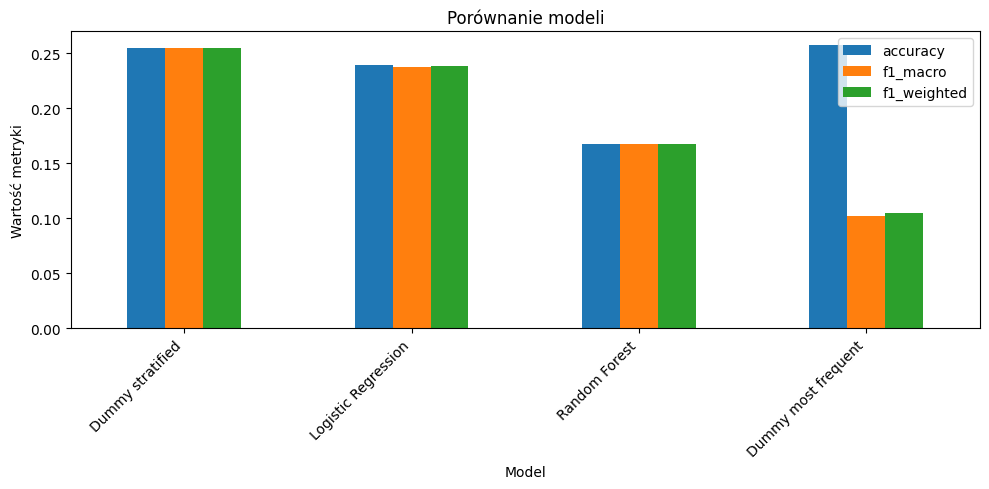

In [17]:
plot_df = results_df.set_index('model')[['accuracy', 'f1_macro', 'f1_weighted']]

plt.figure(figsize=(10, 5))
plot_df.plot(kind='bar', figsize=(10, 5))
plt.title('Porównanie modeli')
plt.ylabel('Wartość metryki')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
